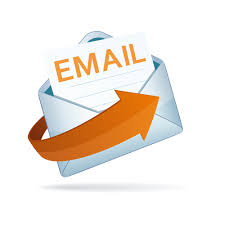

<p style="text-align: center; font-size: 28px;"><b>Email Similarity</b></p>

In this project, you will use scikit-learn’s Naive Bayes implementation on several different datasets. By reporting the accuracy of the classifier, we can find which datasets are harder to distinguish. For example, how difficult do you think it is to distinguish the difference between emails about hockey and emails about soccer? How hard is it to tell the difference between emails about hockey and emails about tech? In this project, we’ll find out exactly how difficult those two tasks are.

In [4]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer

emails = fetch_20newsgroups()

# Exploring the Data

<p style="font-size: 20px;"><b>Task 1</b></p>
We’ve imported a dataset of emails from scikit-learn’s datasets. All of these emails are tagged based on their content.

Print <code>emails.target_names</code> to see the different categories.

In [8]:
print(emails.target_names)

['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


<p style="font-size: 20px;"><b>Task 2</b></p>
We’re interested in seeing how effective our Naive Bayes classifier is at telling the difference between a baseball email and a hockey email. We can select the categories of articles we want from <code>fetch_20newsgroups</code> by adding the parameter <code>categories</code>.

In the function call, set <code>categories</code> equal to the list <code>['rec.sport.baseball', 'rec.sport.hockey']</code>.

In [9]:
emails = fetch_20newsgroups(categories = ['rec.sport.baseball', 'rec.sport.hockey'])

<p style="font-size: 20px;"><b>Task 3</b></p>
Let’s take a look at one of these emails.

All of the emails are stored in a list called <code>emails.data</code>. Print the email at index <code>5</code> in the list.


In [11]:
print(emails.data[5])

From: mmb@lamar.ColoState.EDU (Michael Burger)
Subject: More TV Info
Distribution: na
Nntp-Posting-Host: lamar.acns.colostate.edu
Organization: Colorado State University, Fort Collins, CO  80523
Lines: 36

United States Coverage:
Sunday April 18
  N.J./N.Y.I. at Pittsburgh - 1:00 EDT to Eastern Time Zone
  ABC - Gary Thorne and Bill Clement

  St. Louis at Chicago - 12:00 CDT and 11:00 MDT - to Central/Mountain Zones
  ABC - Mike Emerick and Jim Schoenfeld

  Los Angeles at Calgary - 12:00 PDT and 11:00 ADT - to Pacific/Alaskan Zones
  ABC - Al Michaels and John Davidson

Tuesday, April 20
  N.J./N.Y.I. at Pittsburgh - 7:30 EDT Nationwide
  ESPN - Gary Thorne and Bill Clement

Thursday, April 22 and Saturday April 24
  To Be Announced - 7:30 EDT Nationwide
  ESPN - To Be Announced


Canadian Coverage:

Sunday, April 18
  Buffalo at Boston - 7:30 EDT Nationwide
  TSN - ???

Tuesday, April 20
  N.J.D./N.Y. at Pittsburgh - 7:30 EDT Nationwide
  TSN - ???

Wednesday, April 21
  St. Louis a

<p style="font-size: 20px;"><b>Task 4</b></p>
All of the labels can be found in the list <code>emails.target</code>. Print the label of the email at index <code>5</code>.

The labels themselves are numbers, but those numbers correspond to the label names found at <code>emails.target_names</code>.

Is this a baseball email or a hockey email?


In [12]:
print(emails.target[5])

1


In [13]:
print(emails.target_names)

['rec.sport.baseball', 'rec.sport.hockey']


# Making the Training and Test Sets

<p style="font-size: 20px;"><b>Task 5</b></p>
We now want to split our data into training and test sets. Change the name of your variable from <code>emails</code> to <code>train_emails</code>. Add these three parameters to the function call:

<code>subset='train'</code>  
<code>shuffle=True</code>  
<code>random_state=108</code>

Adding the <code>random_state</code> parameter will make sure that every time you run the code, your dataset is split in the same way.


In [14]:
train_emails = fetch_20newsgroups(categories = ['rec.sport.baseball', 'rec.sport.hockey'], subset='train', shuffle=True, random_state=108)

<p style="font-size: 20px;"><b>Task 6</b></p>
Create another variable named <code>test_emails</code> and set it equal to <code>fetch_20newsgroups</code>. The parameters of the function should be the same as before except <code>subset</code> should now be <code>'test'</code>.


In [15]:
test_emails = fetch_20newsgroups(categories = ['rec.sport.baseball', 'rec.sport.hockey'], subset='test', shuffle=True, random_state=108)

# Counting Words

<p style="font-size: 20px;"><b>Task 7</b></p>
We want to transform these emails into lists of word counts. The <code>CountVectorizer</code> class makes this easy for us.

Create a <code>CountVectorizer</code> object and name it <code>counter</code>.


In [16]:
counter = CountVectorizer()

<p style="font-size: 20px;"><b>Task 8</b></p>
We need to tell <code>counter</code> what possible words can exist in our emails. <code>counter</code> has a <code>.fit()</code> function that takes a list of all your data.

Call <code>.fit()</code> with <code>test_emails.data + train_emails.data</code> as a parameter.


In [17]:
type(test_emails.data)

list

In [18]:
counter.fit(test_emails.data + train_emails.data)

CountVectorizer()

<p style="font-size: 20px;"><b>Task 9</b></p>
We can now make a list of the counts of our words in our training set.

Create a variable named <code>train_counts</code>. Set it equal to <code>counter</code>‘s <code>transform()</code> function using <code>train_emails.data</code> as a parameter.


In [20]:
train_counts = counter.transform(train_emails.data)

<p style="font-size: 20px;"><b>Task 10</b></p>
Let’s also make a variable named <code>test_counts</code>. This should be the same function call as before, but use <code>test_emails.data</code> as the parameter of <code>transform()</code>.


In [21]:
test_counts = counter.transform(test_emails.data)

<p style="font-size: 20px;"><b>Understanding .fit() vs .transform()</b></p>

Let’s clarify the difference between <code>.fit()</code> and <code>.transform()</code> using a simple example:

---

### Example Data
<pre>
train_data = ["I love hockey", "Hockey is fun"]
test_data = ["I love baseball"]
</pre>

---

### Step 1️⃣ — .fit()
When we run:
<pre>
counter.fit(train_data)
</pre>
The vectorizer <b>learns the vocabulary</b> (all unique words) from the training data:

| Word | Index |
|------|--------|
| I | 0 |
| love | 1 |
| hockey | 2 |
| is | 3 |
| fun | 4 |

No vectors are created yet — only this mapping of words to indices.

---

### Step 2️⃣ — .transform()
When we run:
<pre>
counter.transform(train_data)
</pre>
Each sentence is turned into a <b>bag-of-words vector</b> based on that vocabulary:

| Sentence | I | love | hockey | is | fun |
|-----------|---|------|--------|----|-----|
| "I love hockey" | 1 | 1 | 1 | 0 | 0 |
| "Hockey is fun" | 0 | 0 | 1 | 1 | 1 |

---

### Step 3️⃣ — .transform() on Test Data
When we run:
<pre>
counter.transform(test_data)
</pre>
The test sentence is vectorized <b>using the same vocabulary</b>:

| Sentence | I | love | hockey | is | fun |
|-----------|---|------|--------|----|-----|
| "I love baseball" | 1 | 1 | 0 | 0 | 0 |

The word “baseball” is ignored because it wasn’t in the vocabulary learned from the training data.

---

### ✅ Summary
| Method | Purpose | When to Use |
|---------|----------|-------------|
| <code>.fit()</code> | Learns the vocabulary (unique words) | Only on training data |
| <code>.transform()</code> | Converts text to vectors using learned vocabulary | On training and test data |
| <code>.fit_transform()</code> | Shortcut for both steps | On training data only |


# Making a Naive Bayes Classifier

<p style="font-size: 20px;"><b>Task 11</b></p>
Let’s now make a Naive Bayes classifier that we can train and test on. Create a <code>MultinomialNB</code> object named <code>classifier</code>.


In [22]:
classifier = MultinomialNB()

<p style="font-size: 20px;"><b>Task 12</b></p>
Call <code>classifier</code>‘s <code>.fit()</code> function. <code>.fit()</code> takes two parameters. The first should be our training set, which for us is <code>train_counts</code>. The second should be the labels associated with the training emails. Those are found in <code>train_emails.target</code>.


In [24]:
classifier.fit(train_counts, train_emails.target)

MultinomialNB()

<p style="font-size: 20px;"><b>Task 13</b></p>
Test the Naive Bayes Classifier by printing <code>classifier</code>‘s <code>.score()</code> function. <code>.score()</code> takes the test set and the test labels as parameters.

<code>.score()</code> returns the accuracy of the classifier on the test data. Accuracy measures the percentage of classifications a classifier correctly made.


In [29]:
nbc_score = classifier.score(test_counts,  test_emails.target)
print("Model's score:", nbc_score)

Model's score: 0.9723618090452262


<p style="font-size: 20px;"><b>Understanding the Multinomial Naive Bayes Classifier</b></p>

The <code>MultinomialNB</code> model is a probabilistic classifier that works particularly well with <b>discrete features</b> such as word counts — exactly what we get from <code>CountVectorizer</code>.  
It applies <b>Bayes’ Theorem</b>, which calculates the probability of a class (like “baseball” or “hockey”) given a set of observed features (the words in an email).

---

### 🧠 Intuition from the Example
Imagine we’ve already transformed our emails into word-count vectors using <code>CountVectorizer</code>:

| Sentence | I | love | hockey | is | fun |
|-----------|---|------|--------|----|-----|
| "I love hockey" | 1 | 1 | 1 | 0 | 0 |
| "Hockey is fun" | 0 | 0 | 1 | 1 | 1 |

Now, the classifier looks at all words across the <b>training set</b> and learns:
- How often each word appears in baseball vs hockey emails.  
- How likely each word is to appear in a given category.

For example:  
<pre>
P("hockey" | hockey_email) = high  
P("hockey" | baseball_email) = low
</pre>

Then, when a new sentence like “I love baseball” appears, it multiplies these probabilities to find:  
<pre>
P(hockey | "I love baseball")
P(baseball | "I love baseball")
</pre>
and predicts the class with the higher probability.

---

### ⚙️ Why "Multinomial"?
The model assumes that:
- Words are drawn from a <b>multinomial distribution</b>, meaning each word’s count contributes independently to the probability of the document.  
- The <b>frequency</b> of each word matters (not just its presence).  

So a word repeated several times increases its influence on the prediction.

---

### ✅ Summary
| Concept | Description |
|----------|--------------|
| **Model type** | Probabilistic classifier based on Bayes’ Theorem |
| **Ideal data** | Discrete features like word counts |
| **Assumption** | Words occur independently and follow a multinomial distribution |
| **Output** | Probability of each class given the observed words |

In short, <code>MultinomialNB</code> is simple, fast, and very effective for <b>text classification tasks</b> like distinguishing between baseball and hockey emails.


# Testing Other Datasets

In [30]:
# Step 1: Define the new categories for comparison
categories = ['comp.sys.ibm.pc.hardware', 'rec.sport.hockey']

# Step 2: Create the training and testing datasets with the new categories
train_emails = fetch_20newsgroups(subset='train',
                                  categories=categories,
                                  shuffle=True,
                                  random_state=108)

test_emails = fetch_20newsgroups(subset='test',
                                 categories=categories,
                                 shuffle=True,
                                 random_state=108)

In [31]:
# Step 3: Transform the text data into count vectors
from sklearn.feature_extraction.text import CountVectorizer

counter = CountVectorizer()
counter.fit(test_emails.data + train_emails.data)

train_counts = counter.transform(train_emails.data)
test_counts = counter.transform(test_emails.data)

# Step 4: Train and test the Naive Bayes classifier
from sklearn.naive_bayes import MultinomialNB

classifier = MultinomialNB()
classifier.fit(train_counts, train_emails.target)

# Step 5: Evaluate the classifier’s performance
accuracy = classifier.score(test_counts, test_emails.target)
print(f"Accuracy on ['comp.sys.ibm.pc.hardware', 'rec.sport.hockey']: {accuracy:.4f}")

Accuracy on ['comp.sys.ibm.pc.hardware', 'rec.sport.hockey']: 0.9975


<p style="font-size: 20px;"><b>Task 15</b></p>
Play around with different sets of data. Can you find a set that’s incredibly accurate or incredibly inaccurate?

The possible categories are listed below.

<pre>
'alt.atheism'
'comp.graphics'
'comp.os.ms-windows.misc'
'comp.sys.ibm.pc.hardware'
'comp.sys.mac.hardware'
'comp.windows.x'
'misc.forsale'
'rec.autos'
'rec.motorcycles'
'rec.sport.baseball'
'rec.sport.hockey'
'sci.crypt'
'sci.electronics'
'sci.med'
'sci.space'
'soc.religion.christian'
'talk.politics.guns'
'talk.politics.mideast'
'talk.politics.misc'
'talk.religion.misc'
</pre>


In [33]:
# Step 1: Choose any two categories to test how accuracy changes
# Try pairs like ['rec.sport.hockey', 'rec.sport.baseball'] or ['sci.space', 'talk.religion.misc']
categories = ['sci.space', 'talk.religion.misc']

# Step 2: Load training and test data for the selected categories
train_emails = fetch_20newsgroups(subset='train',
                                  categories=categories,
                                  shuffle=True,
                                  random_state=108)

test_emails = fetch_20newsgroups(subset='test',
                                 categories=categories,
                                 shuffle=True,
                                 random_state=108)

# Step 3: Transform the text data into count vectors
from sklearn.feature_extraction.text import CountVectorizer

counter = CountVectorizer()
counter.fit(train_emails.data)  # Fit only on training data (best practice)

train_counts = counter.transform(train_emails.data)
test_counts = counter.transform(test_emails.data)

# Step 4: Train and test the Naive Bayes classifier
from sklearn.naive_bayes import MultinomialNB

classifier = MultinomialNB()
classifier.fit(train_counts, train_emails.target)

# Step 5: Evaluate the classifier’s performance
accuracy = classifier.score(test_counts, test_emails.target)

print(f"Accuracy on categories {categories}: {accuracy:.4f}")

Accuracy on categories ['sci.space', 'talk.religion.misc']: 0.9783


In [34]:
# Step 1: Choose any two categories to test how accuracy changes
# Try pairs like ['rec.sport.hockey', 'rec.sport.baseball'] or ['sci.space', 'talk.religion.misc']
categories = ['rec.autos', 'rec.motorcycles']

# Step 2: Load training and test data for the selected categories
train_emails = fetch_20newsgroups(subset='train',
                                  categories=categories,
                                  shuffle=True,
                                  random_state=108)

test_emails = fetch_20newsgroups(subset='test',
                                 categories=categories,
                                 shuffle=True,
                                 random_state=108)

# Step 3: Transform the text data into count vectors
from sklearn.feature_extraction.text import CountVectorizer

counter = CountVectorizer()
counter.fit(train_emails.data)  # Fit only on training data (best practice)

train_counts = counter.transform(train_emails.data)
test_counts = counter.transform(test_emails.data)

# Step 4: Train and test the Naive Bayes classifier
from sklearn.naive_bayes import MultinomialNB

classifier = MultinomialNB()
classifier.fit(train_counts, train_emails.target)

# Step 5: Evaluate the classifier’s performance
accuracy = classifier.score(test_counts, test_emails.target)

print(f"Accuracy on categories {categories}: {accuracy:.4f}")

Accuracy on categories ['rec.autos', 'rec.motorcycles']: 0.9786


In [35]:
# Step 1: Choose any two categories to test how accuracy changes

categories = ['comp.graphics', 'sci.med']


# Step 2: Load training and test data for the selected categories
train_emails = fetch_20newsgroups(subset='train',
                                  categories=categories,
                                  shuffle=True,
                                  random_state=108)

test_emails = fetch_20newsgroups(subset='test',
                                 categories=categories,
                                 shuffle=True,
                                 random_state=108)

# Step 3: Transform the text data into count vectors
from sklearn.feature_extraction.text import CountVectorizer

counter = CountVectorizer()
counter.fit(train_emails.data)  # Fit only on training data (best practice)

train_counts = counter.transform(train_emails.data)
test_counts = counter.transform(test_emails.data)

# Step 4: Train and test the Naive Bayes classifier
from sklearn.naive_bayes import MultinomialNB

classifier = MultinomialNB()
classifier.fit(train_counts, train_emails.target)

# Step 5: Evaluate the classifier’s performance
accuracy = classifier.score(test_counts, test_emails.target)

print(f"Accuracy on categories {categories}: {accuracy:.4f}")

Accuracy on categories ['comp.graphics', 'sci.med']: 0.9682


In [36]:
# Step 1: Choose any two categories to test how accuracy changes
# Try pairs like ['rec.sport.hockey', 'rec.sport.baseball'] or ['sci.space', 'talk.religion.misc']
categories = categories = ['talk.politics.guns', 'soc.religion.christian']

# Step 2: Load training and test data for the selected categories
train_emails = fetch_20newsgroups(subset='train',
                                  categories=categories,
                                  shuffle=True,
                                  random_state=108)

test_emails = fetch_20newsgroups(subset='test',
                                 categories=categories,
                                 shuffle=True,
                                 random_state=108)

# Step 3: Transform the text data into count vectors
from sklearn.feature_extraction.text import CountVectorizer

counter = CountVectorizer()
counter.fit(train_emails.data)  # Fit only on training data (best practice)

train_counts = counter.transform(train_emails.data)
test_counts = counter.transform(test_emails.data)

# Step 4: Train and test the Naive Bayes classifier
from sklearn.naive_bayes import MultinomialNB

classifier = MultinomialNB()
classifier.fit(train_counts, train_emails.target)

# Step 5: Evaluate the classifier’s performance
accuracy = classifier.score(test_counts, test_emails.target)

print(f"Accuracy on categories {categories}: {accuracy:.4f}")

Accuracy on categories ['talk.politics.guns', 'soc.religion.christian']: 0.9948
